# Higher-Order GAT on Cell Complexes: Synthetic Binary Classification

This notebook trains the `HOGATGraphClassifier` (a Graph-Attention-Network
generalized to cell complexes -- nodes, edges *and* polygons) on a small,
synthetic binary classification task, and visualizes the learned attention
scores on edges and polygons.

**The task.** Two families of "strip" cell complexes are generated:
- **triangle strips** (label 0): a chain of triangles sharing edges.
- **square strips** (label 1): a chain of squares (a ladder graph) sharing edges.

The two classes differ in the *shape* of their polygons (3-cycles vs.
4-cycles), so a model needs to genuinely use polygon-level (rank-2)
information -- not just node or edge features -- to tell them apart.


In [1]:
import sys
from pathlib import Path

# Make sure the local `hogat` package (next to this notebook) is importable.
sys.path.insert(0, str(Path.cwd()))

import random

import matplotlib.pyplot as plt
import torch

from synthetic import make_synthetic_dataset
from hogat_classifier import HOGATGraphClassifier
from plot import edge_and_polygon_attention_scores, plot_complex_with_attention

SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)

from hogat_infomax import HOGATInfomax


## 1. Generate the synthetic dataset

In [2]:
dataset = make_synthetic_dataset(
    n_samples=200,
    k_min=2,
    k_max=8,
    feat_dim=4,   # 3 noise dims + 1 structural "degree" dim per rank
    noise=0.3,
    seed=SEED,
)

n_train = 160
train_set, test_set = dataset[:n_train], dataset[n_train:]

print(f"total samples : {len(dataset)}")
print(f"train / test  : {len(train_set)} / {len(test_set)}")
print(f"class balance (train): "
      f"{sum(s['label'].item() for s in train_set):.0f} positive / {len(train_set)}")
print(f"class balance (test) : "
      f"{sum(s['label'].item() for s in test_set):.0f} positive / {len(test_set)}")


total samples : 200
train / test  : 160 / 40
class balance (train): 81 positive / 160
class balance (test) : 19 positive / 40


### A look at the data

One triangle strip and one square strip, drawn to scale (no attention yet).

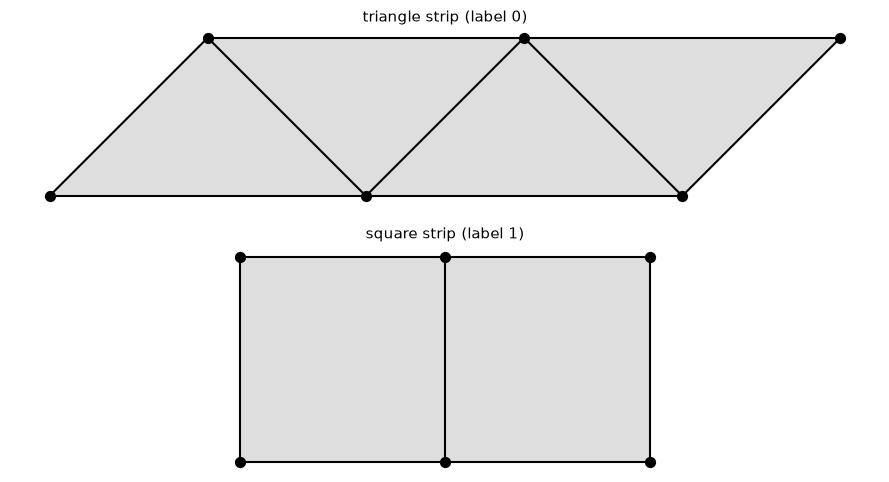

In [3]:
triangle_example = next(s for s in dataset if s["family"] == "triangle")
square_example = next(s for s in dataset if s["family"] == "square")

fig, axes = plt.subplots(2, 1, figsize=(9, 5))
plot_complex_with_attention(triangle_example, ax=axes[0], title="triangle strip (label 0)")
plot_complex_with_attention(square_example, ax=axes[1], title="square strip (label 1)")
fig.tight_layout()
plt.show()


## 2. Build the model

In [ ]:
model = HOGATGraphClassifier(
    in_channels_0=4,
    in_channels_1=4,
    in_channels_2=4,
    hid_channels=16,
    n_layers=2,
    heads=4,
    concat=False,
    dropout=0.1,
)

optimizer = torch.optim.Adam(model.parameters(), lr=5e-3, weight_decay=1e-4)
loss_fn = torch.nn.BCEWithLogitsLoss()

n_params = sum(p.numel() for p in model.parameters())
print(model)
print(f"\ntotal trainable parameters: {n_params}")


## 3. Train

Since complexes have different numbers of nodes/edges/polygons, each
complex is passed through the model individually; a "mini-batch" is
formed simply by summing the losses of several complexes before calling
`.backward()` once. This keeps the code simple while still batching the
optimizer updates.


In [ ]:
def forward(sample):
    return model(
        sample["x_0"], sample["x_1"], sample["x_2"],
        sample["adjacency_0_up"],
        sample["incidence_1"], sample["incidence_1_t"],
        sample["adjacency_1_down"], sample["adjacency_1_up"],
        sample["incidence_2"], sample["incidence_2_t"],
        sample["adjacency_2_down"],
    )


@torch.no_grad()
def evaluate(samples):
    model.eval()
    total_loss, correct = 0.0, 0
    for sample in samples:
        logit = forward(sample)
        total_loss += loss_fn(logit, sample["label"]).item()
        pred = (logit > 0).float()
        correct += int(pred.item() == sample["label"].item())
    return total_loss / len(samples), correct / len(samples)


In [ ]:
N_EPOCHS = 25
BATCH_SIZE = 10

history = {"train_loss": [], "test_loss": [], "train_acc": [], "test_acc": []}

for epoch in range(N_EPOCHS):
    model.train()
    epoch_samples = train_set.copy()
    random.shuffle(epoch_samples)

    for i in range(0, len(epoch_samples), BATCH_SIZE):
        batch = epoch_samples[i : i + BATCH_SIZE]
        optimizer.zero_grad()
        batch_loss = sum(loss_fn(forward(s), s["label"]) for s in batch) / len(batch)
        batch_loss.backward()
        optimizer.step()

    train_loss, train_acc = evaluate(train_set)
    test_loss, test_acc = evaluate(test_set)
    history["train_loss"].append(train_loss)
    history["test_loss"].append(test_loss)
    history["train_acc"].append(train_acc)
    history["test_acc"].append(test_acc)

    if epoch % 5 == 0 or epoch == N_EPOCHS - 1:
        print(
            f"epoch {epoch:2d} | "
            f"train_loss={train_loss:.4f} train_acc={train_acc:.3f} | "
            f"test_loss={test_loss:.4f} test_acc={test_acc:.3f}"
        )


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))

axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["test_loss"], label="test")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("BCE loss")
axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(history["train_acc"], label="train")
axes[1].plot(history["test_acc"], label="test")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("accuracy")
axes[1].set_title("Accuracy")
axes[1].set_ylim(0, 1.05)
axes[1].legend()

fig.tight_layout()
plt.show()

print(f"final test accuracy: {history['test_acc'][-1]:.3f}")


## 4. Visualizing attention on edges and polygons

For one test complex from each class, we run a forward pass with
`return_attention=True` and pull out the last layer's attention. We then
compute:

- an **edge score**: how much attention the complex's *polygons*
  collectively place on each edge (from the `poly_boundary` neighborhood,
  i.e. polygons attending to their bounding edges),
- a **polygon score**: how much attention the complex's *edges*
  collectively place on each polygon (from the `edge_coboundary`
  neighborhood, i.e. edges attending to their incident polygons).

Edges are drawn thicker/darker (blue) and polygons shaded darker (orange)
where they receive more attention.


In [ ]:
def pick_example(samples, family):
    for sample in samples:
        if sample["family"] == family:
            return sample
    raise ValueError(f"no {family} example found")


model.eval()
examples = [pick_example(test_set, "triangle"), pick_example(test_set, "square")]

fig, axes = plt.subplots(2, 1, figsize=(9, 6))

for ax, sample in zip(axes, examples):
    with torch.no_grad():
        logit, all_attention = model(
            sample["x_0"], sample["x_1"], sample["x_2"],
            sample["adjacency_0_up"],
            sample["incidence_1"], sample["incidence_1_t"],
            sample["adjacency_1_down"], sample["adjacency_1_up"],
            sample["incidence_2"], sample["incidence_2_t"],
            sample["adjacency_2_down"],
            return_attention=True,
        )
    pred_label = int((logit > 0).float().item())
    last_layer_attention = all_attention[-1]
    edge_scores, poly_scores = edge_and_polygon_attention_scores(sample, last_layer_attention)

    true_label = int(sample["label"].item())
    title = (
        f"{sample['family']} strip  |  true label={true_label}, "
        f"predicted={pred_label}  |  logit={logit.item():.2f}"
    )
    plot_complex_with_attention(sample, edge_scores, poly_scores, ax=ax, title=title)

fig.tight_layout()
plt.show()


### Bonus: attention across layers

The model has two `HOGATLayer`s. Comparing the attention of the first
layer (closer to the raw, mostly-noise features) against the last layer
(after one round of higher-order message passing) shows how attention
sharpens as the model refines its representation.


In [ ]:
sample = examples[0]  # triangle-strip example from above

with torch.no_grad():
    _, all_attention = model(
        sample["x_0"], sample["x_1"], sample["x_2"],
        sample["adjacency_0_up"],
        sample["incidence_1"], sample["incidence_1_t"],
        sample["adjacency_1_down"], sample["adjacency_1_up"],
        sample["incidence_2"], sample["incidence_2_t"],
        sample["adjacency_2_down"],
        return_attention=True,
    )

fig, axes = plt.subplots(len(all_attention), 1, figsize=(9, 3 * len(all_attention)))
if len(all_attention) == 1:
    axes = [axes]

for layer_idx, (ax, layer_attention) in enumerate(zip(axes, all_attention)):
    edge_scores, poly_scores = edge_and_polygon_attention_scores(sample, layer_attention)
    plot_complex_with_attention(
        sample, edge_scores, poly_scores, ax=ax, title=f"layer {layer_idx} attention"
    )

fig.tight_layout()
plt.show()


## 5. Deep Graph Infomax

In [4]:
model = HOGATGraphClassifier(
    in_channels_0=4,
    in_channels_1=4,
    in_channels_2=4,
    hid_channels=16,
    n_layers=2,
    heads=4,
    concat=False,
    dropout=0.1,
)

optimizer = torch.optim.Adam(model.parameters(), lr=5e-3, weight_decay=1e-4)
loss_fn = torch.nn.BCEWithLogitsLoss()

n_params = sum(p.numel() for p in model.parameters())
print(model)
print(f"\ntotal trainable parameters: {n_params}")

HOGATGraphClassifier(
  (backbone): HOGAT(
    (proj_0): Linear(in_features=4, out_features=16, bias=True)
    (proj_1): Linear(in_features=4, out_features=16, bias=True)
    (proj_2): Linear(in_features=4, out_features=16, bias=True)
    (layers): ModuleList(
      (0-1): 2 x HOGATLayer(
        (conv_0_coboundary): SparseCellAttention(
          (lin_source): Linear(in_features=16, out_features=64, bias=False)
          (lin_target): Linear(in_features=16, out_features=64, bias=False)
        )
        (conv_0_up): SparseCellAttention(
          (lin_source): Linear(in_features=16, out_features=64, bias=False)
          (lin_target): Linear(in_features=16, out_features=64, bias=False)
        )
        (lin_0): Linear(in_features=32, out_features=16, bias=True)
        (conv_1_boundary): SparseCellAttention(
          (lin_source): Linear(in_features=16, out_features=64, bias=False)
          (lin_target): Linear(in_features=16, out_features=64, bias=False)
        )
        (conv_1_

In [5]:
model = HOGATInfomax(in_channels_0=4, 
                     in_channels_1=4, 
                     in_channels_2=4,
                     hid_channels=16, 
                     n_layers=2, 
                     heads=4,
                     concat=False,
                     dropout=0.1,
)

optimizer = torch.optim.Adam(model.parameters(), lr=5e-3, weight_decay=1e-4)

n_params = sum(p.numel() for p in model.parameters())
print(model)
print(f"\ntotal trainable parameters: {n_params}")

HOGATInfomax(
  (backbone): HOGAT(
    (proj_0): Linear(in_features=4, out_features=16, bias=True)
    (proj_1): Linear(in_features=4, out_features=16, bias=True)
    (proj_2): Linear(in_features=4, out_features=16, bias=True)
    (layers): ModuleList(
      (0-1): 2 x HOGATLayer(
        (conv_0_coboundary): SparseCellAttention(
          (lin_source): Linear(in_features=16, out_features=64, bias=False)
          (lin_target): Linear(in_features=16, out_features=64, bias=False)
        )
        (conv_0_up): SparseCellAttention(
          (lin_source): Linear(in_features=16, out_features=64, bias=False)
          (lin_target): Linear(in_features=16, out_features=64, bias=False)
        )
        (lin_0): Linear(in_features=32, out_features=16, bias=True)
        (conv_1_boundary): SparseCellAttention(
          (lin_source): Linear(in_features=16, out_features=64, bias=False)
          (lin_target): Linear(in_features=16, out_features=64, bias=False)
        )
        (conv_1_cobounda

In [6]:
def forward(sample):
    return model(
        sample["x_0"], sample["x_1"], sample["x_2"],
        sample["adjacency_0_up"],
        sample["incidence_1"], sample["incidence_1_t"],
        sample["adjacency_1_down"], sample["adjacency_1_up"],
        sample["incidence_2"], sample["incidence_2_t"],
        sample["adjacency_2_down"],
    )


@torch.no_grad()
def discriminator_accuracy(pos, neg, summary):
    """Fraction of correct real-vs-corrupted calls, at each rank, averaged."""
    correct, total = 0, 0
    for pz, nz in zip(pos, neg):
        pos_pred = (model.discriminate(pz, summary) > 0.5).float()
        neg_pred = (model.discriminate(nz, summary) > 0.5).float()
        correct += pos_pred.sum().item() + (1 - neg_pred).sum().item()
        total += pos_pred.numel() + neg_pred.numel()
    return correct / total


@torch.no_grad()
def evaluate(samples):
    model.eval()
    total_loss, total_acc = 0.0, 0.0
    for sample in samples:
        pos, neg, summary = forward(sample)
        total_loss += model.loss(pos, neg, summary).item()
        total_acc += discriminator_accuracy(pos, neg, summary)
    return total_loss / len(samples), total_acc / len(samples)




In [7]:
N_EPOCHS = 25
BATCH_SIZE = 10

history = {"train_loss": [], "test_loss": [], "train_acc": [], "test_acc": []}

for epoch in range(N_EPOCHS):
    model.train()
    epoch_samples = train_set.copy()
    random.shuffle(epoch_samples)

    for i in range(0, len(epoch_samples), BATCH_SIZE):
        batch = epoch_samples[i : i + BATCH_SIZE]
        optimizer.zero_grad()
        batch_loss = 0.0
        for s in batch:
            pos, neg, summary = forward(s)
            batch_loss = batch_loss + model.loss(pos, neg, summary)
        batch_loss = batch_loss / len(batch)
        batch_loss.backward()
        optimizer.step()

    train_loss, train_acc = evaluate(train_set)
    test_loss, test_acc = evaluate(test_set)
    history["train_loss"].append(train_loss)
    history["test_loss"].append(test_loss)
    history["train_acc"].append(train_acc)
    history["test_acc"].append(test_acc)

    if epoch % 5 == 0 or epoch == N_EPOCHS - 1:
        print(
            f"epoch {epoch:2d} | "
            f"train_loss={train_loss:.4f} train_acc={train_acc:.3f} | "
            f"test_loss={test_loss:.4f} test_acc={test_acc:.3f}"
        )

epoch  0 | train_loss=3.9597 train_acc=0.632 | test_loss=3.9469 test_acc=0.642
epoch  5 | train_loss=1.2475 train_acc=0.933 | test_loss=1.1866 test_acc=0.935
epoch 10 | train_loss=0.5583 train_acc=0.976 | test_loss=0.4364 test_acc=0.984
epoch 15 | train_loss=0.4458 train_acc=0.977 | test_loss=0.3549 test_acc=0.982
epoch 20 | train_loss=0.4066 train_acc=0.980 | test_loss=0.6134 test_acc=0.972
epoch 24 | train_loss=0.5280 train_acc=0.973 | test_loss=0.1610 test_acc=0.990


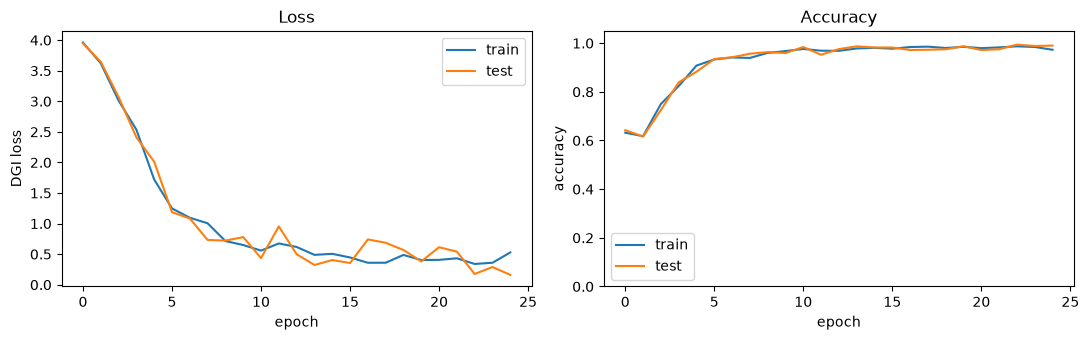

final test accuracy: 0.990


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))

axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["test_loss"], label="test")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("DGI loss")
axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(history["train_acc"], label="train")
axes[1].plot(history["test_acc"], label="test")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("accuracy")
axes[1].set_title("Accuracy")
axes[1].set_ylim(0, 1.05)
axes[1].legend()

fig.tight_layout()
plt.show()

print(f"final test accuracy: {history['test_acc'][-1]:.3f}")


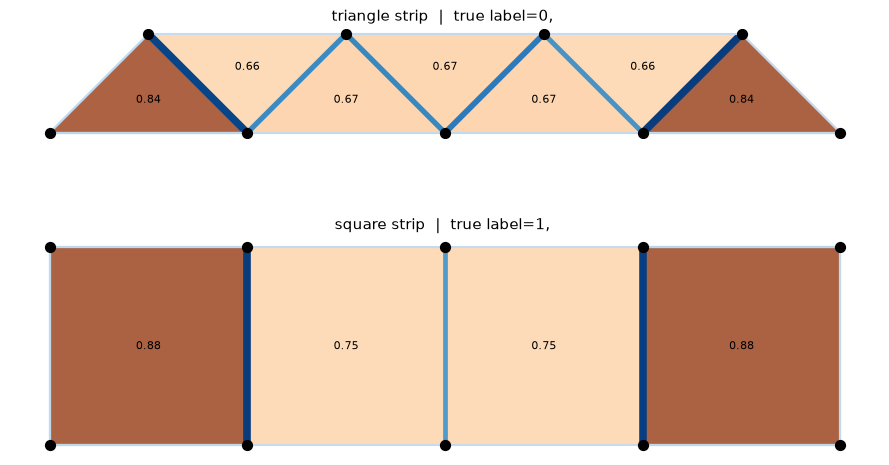

In [11]:
def pick_example(samples, family):
    for sample in samples:
        if sample["family"] == family:
            return sample
    raise ValueError(f"no {family} example found")


model.eval()
examples = [pick_example(test_set, "triangle"), pick_example(test_set, "square")]

fig, axes = plt.subplots(2, 1, figsize=(9, 6))

for ax, sample in zip(axes, examples):
    with torch.no_grad():
        pos, neg, summary, all_attention = model(
            sample["x_0"], sample["x_1"], sample["x_2"],
            sample["adjacency_0_up"],
            sample["incidence_1"], sample["incidence_1_t"],
            sample["adjacency_1_down"], sample["adjacency_1_up"],
            sample["incidence_2"], sample["incidence_2_t"],
            sample["adjacency_2_down"],
            return_attention=True,
        )
    #pred_label = int((logit > 0).float().item())
    last_layer_attention = all_attention[-1]
    edge_scores, poly_scores = edge_and_polygon_attention_scores(sample, last_layer_attention)

    true_label = int(sample["label"].item())
    title = (
        f"{sample['family']} strip  |  true label={true_label}, "
        #f"predicted={pred_label}  |  logit={logit.item():.2f}"
    )
    plot_complex_with_attention(sample, edge_scores, poly_scores, ax=ax, title=title)

fig.tight_layout()
plt.show()


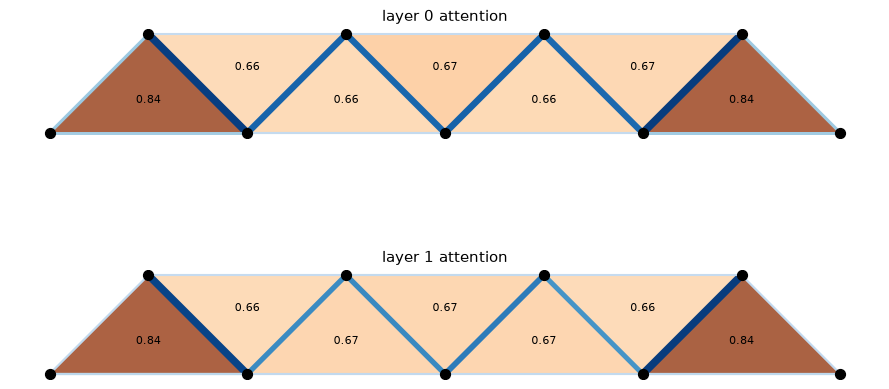

In [15]:
sample = examples[0]  # triangle-strip example from above

with torch.no_grad():
    pos, neg, summary, all_attention = model(
            sample["x_0"], sample["x_1"], sample["x_2"],
            sample["adjacency_0_up"],
            sample["incidence_1"], sample["incidence_1_t"],
            sample["adjacency_1_down"], sample["adjacency_1_up"],
            sample["incidence_2"], sample["incidence_2_t"],
            sample["adjacency_2_down"],
            return_attention=True,
        )

fig, axes = plt.subplots(len(all_attention), 1, figsize=(9, 3 * len(all_attention)))
if len(all_attention) == 1:
    axes = [axes]

for layer_idx, (ax, layer_attention) in enumerate(zip(axes, all_attention)):
    edge_scores, poly_scores = edge_and_polygon_attention_scores(sample, layer_attention)
    plot_complex_with_attention(
        sample, edge_scores, poly_scores, ax=ax, title=f"layer {layer_idx} attention"
    )

fig.tight_layout()
plt.show()
